# 06 — Transfer Learning with MobileNetV2 on CIFAR-10

**Project:** Progressive CNN Classifier Study
**Stage:** 6 of 6 (Final) — Transfer Learning

### Goal
Every previous notebook trained a CNN **from scratch**. This one instead takes **MobileNetV2**, pretrained on ImageNet (1.4M images, 1000 classes), and fine-tunes it for CIFAR-10's 10 classes. This tests whether features learned from a huge, general dataset transfer better than anything we could train from scratch on CIFAR-10 alone.

### Scoreboard so far
| Notebook | Technique | Test Accuracy | Test Loss |
|---|---|---|---|
| 01 | Baseline | 0.7166 | 0.8821 |
| 02 | + BatchNorm | 0.6807 | 1.5024 |
| 03 | + BatchNorm + Dropout | 0.7250 | 0.7805 |
| 04 / 04b | + Data Augmentation | 0.6359 / 0.6680 |
| 05 | + LR Scheduling | **0.7407** | **0.7296** |
| 06 | Transfer Learning (MobileNetV2) | 0.8928 | 0.3232 |

### Why MobileNetV2?
Chosen for this MacBook Air (CPU-only, no working Metal GPU acceleration): MobileNetV2 has ~3.5M parameters vs. ResNet50's ~25M, making it dramatically faster to fine-tune on CPU while still transferring strong ImageNet features.

### Key challenge: input size mismatch
MobileNetV2 expects images at least 96×96 (ideally 224×224); CIFAR-10 images are only 32×32. We resize images up using a `Resizing` layer inside the model.

### Transfer learning strategy: feature extraction, then fine-tuning
1. **Phase 1 — Feature extraction:** freeze all MobileNetV2 layers, train only a new classifier head on top. Fast, and prevents destroying pretrained weights with large early gradients.
2. **Phase 2 — Fine-tuning:** unfreeze the top portion of MobileNetV2 and continue training with a very low learning rate, letting it adapt its higher-level features specifically to CIFAR-10.

### What this notebook covers
- Loading a pretrained model without its original classifier head
- Freezing/unfreezing layers
- Two-phase training (feature extraction → fine-tuning)
- Comparing against every from-scratch model in this project

## 1. Imports

In [11]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. Load CIFAR-10

**Important difference from previous notebooks:** we do NOT manually divide by 255 here. MobileNetV2 has its own `preprocess_input` function (expects a specific input scaling that ImageNet-pretrained models were trained with), which we apply as a layer inside the model instead.

In [12]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 3. Load Pretrained MobileNetV2 (Feature Extractor)

- `include_top=False` — drop MobileNetV2's original 1000-class ImageNet classifier head; we'll add our own 10-class head.
- `weights="imagenet"` — load pretrained weights (downloads once, ~9MB, then cached).
- `input_shape=(96, 96, 3)` — the minimum size MobileNetV2 accepts.
- `base_model.trainable = False` — freeze all pretrained weights for Phase 1.

In [13]:
IMG_SIZE = 96

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print(f"Base model has {len(base_model.layers)} layers")
print(f"Trainable: {base_model.trainable}")

Base model has 154 layers
Trainable: False


## 4. Build the Full Model

Pipeline: raw 32×32 image -> resize to 96×96 -> MobileNetV2 preprocessing -> frozen MobileNetV2 base -> global pooling -> our new dense classifier head.

`GlobalAveragePooling2D` replaces `Flatten()` here — it's the standard choice for transfer learning: it averages each feature map down to a single number, keeping the parameter count of the new head small and reducing overfitting risk on top of a large pretrained backbone.

In [14]:
inputs = layers.Input(shape=(32, 32, 3))
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = layers.Lambda(preprocess_input)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Phase 1 — Train the Classifier Head (Base Frozen)

Only our new Dense layers are trainable right now — MobileNetV2's ~2.2M pretrained parameters stay frozen. This is fast since gradients only flow through the small head.

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_phase1 = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/8
765/782 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7660 - loss: 0.6952

KeyboardInterrupt: 

## 6. Phase 2 — Fine-Tune the Top of MobileNetV2

Now we unfreeze the **last 30 layers** of MobileNetV2 (its highest-level, most task-specific features) and continue training with a much smaller learning rate (`1e-5` vs `1e-3`). A tiny learning rate here is critical — large updates would wreck the carefully pretrained weights instead of gently adapting them.

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfrozen layers in base model: {trainable_count} / {len(base_model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_phase2 = model.fit(
    x_train, y_train,
    epochs=7,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Unfrozen layers in base model: 30 / 154
Epoch 1/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 91ms/step - accuracy: 0.8055 - loss: 0.6496 - val_accuracy: 0.8684 - val_loss: 0.4020
Epoch 2/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.8413 - loss: 0.4852 - val_accuracy: 0.8757 - val_loss: 0.3709
Epoch 3/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.8618 - loss: 0.4153 - val_accuracy: 0.8799 - val_loss: 0.3526
Epoch 4/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.8763 - loss: 0.3699 - val_accuracy: 0.8809 - val_loss: 0.3456
Epoch 5/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.8855 - loss: 0.3367 - val_accuracy: 0.8881 - val_loss: 0.3335
Epoch 6/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 89ms/step - accuracy: 0.8945 - loss: 0.3031 - val_accuracy: 0.8916 - val_loss: 0.3283
Epoch 7/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 89ms/step - accuracy: 0.9002 - loss: 0.2864 - val_accuracy: 0.8928 - val_loss: 0.3232


## 7. Save the Model

In [ ]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

model.save("models/transfer_learning_mobilenetv2.h5")
print("Model saved to models/transfer_learning_mobilenetv2.h5")

Model saved to models/transfer_learning_mobilenetv2.h5


## 8. Visualize Training Curves (Both Phases Combined)

We stitch Phase 1 and Phase 2 histories together into one continuous timeline, with a vertical line marking where fine-tuning began.

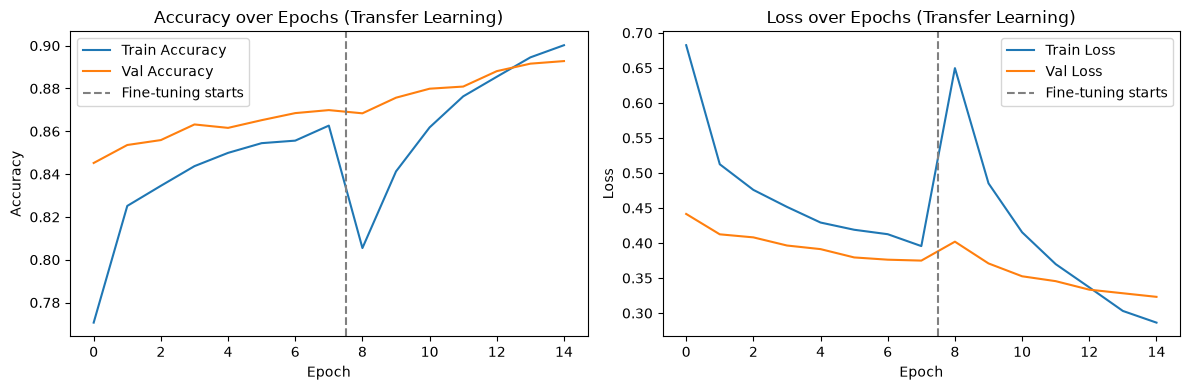

In [ ]:
acc = history_phase1.history["accuracy"] + history_phase2.history["accuracy"]
val_acc = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
loss = history_phase1.history["loss"] + history_phase2.history["loss"]
val_loss = history_phase1.history["val_loss"] + history_phase2.history["val_loss"]

phase1_epochs = len(history_phase1.history["accuracy"])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.axvline(phase1_epochs - 0.5, color="gray", linestyle="--", label="Fine-tuning starts")
plt.title("Accuracy over Epochs (Transfer Learning)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.axvline(phase1_epochs - 0.5, color="gray", linestyle="--", label="Fine-tuning starts")
plt.title("Loss over Epochs (Transfer Learning)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("results/transfer_learning_curves.png")
plt.show()

## 9. Final Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8928 - loss: 0.3232
Final Test Accuracy: 0.8928
Final Test Loss: 0.3232


## 10. Final Comparison — All 6 Stages

In [ ]:
results_table = [
    ("Baseline (01)", 0.7166, 0.8821),
    ("BatchNorm (02)", 0.6807, 1.5024),
    ("BatchNorm + Dropout (03)", 0.7250, 0.7805),
    ("+ Augmentation (04)", 0.6359, 1.0204),
    ("+ Augmentation, 35ep (04b)", 0.6680, 0.9441),
    ("03 + LR Scheduling (05)", 0.7407, 0.7296),
    ("Transfer Learning MobileNetV2 (06)", test_acc, test_loss),
]

print(f"{'Model':<38}{'Test Accuracy':<18}{'Test Loss':<12}")
for name, acc_, loss_ in results_table:
    print(f"{name:<38}{acc_:<18.4f}{loss_:<12.4f}")

print(f"\nAccuracy change vs best from-scratch model (05): {test_acc - 0.7407:+.4f}")

Model                                 Test Accuracy     Test Loss   
Baseline (01)                         0.7166            0.8821      
BatchNorm (02)                        0.6807            1.5024      
BatchNorm + Dropout (03)              0.7250            0.7805      
+ Augmentation (04)                   0.6359            1.0204      
+ Augmentation, 35ep (04b)            0.6680            0.9441      
03 + LR Scheduling (05)               0.7407            0.7296      
Transfer Learning MobileNetV2 (06)    0.8928            0.3232      

Accuracy change vs best from-scratch model (05): +0.1521


## Project Summary

| Stage | Technique | Concept Demonstrated | Test Accuracy |
|---|---|---|---|
| 01 | Baseline CNN | Conv/Pool/Dense fundamentals, backprop | 0.7166 |
| 02 | + BatchNorm | Normalization, internal covariate shift | 0.6807 |
| 03 | + Dropout | Regularization, co-adaptation prevention | 0.7250 |
| 04/04b | + Data Augmentation | Data-level regularization, training dynamics | 0.6359 / 0.6680 |
| 05 | + LR Scheduling | Adaptive optimization | **0.7407** |
| 06 | Transfer Learning | Pretrained features, fine-tuning | 0.8928 |

**What this project demonstrates end-to-end:**
- Core CNN architecture (Conv2D, Pooling, Dense, Flatten)
- Regularization techniques (BatchNorm, Dropout) and how they interact (BatchNorm alone hurt generalization; combined with Dropout it became the best from-scratch config)
- Data-level augmentation and its limits on low-resolution datasets
- Adaptive learning rate scheduling and convergence behavior
- Transfer learning: feature extraction vs. fine-tuning, freezing/unfreezing layers, and the trade-offs of pretrained models vs. training from scratch
- Rigorous experimental methodology: identical conditions across runs, isolating one variable per notebook, diagnosing *why* results occurred rather than only reporting numbers

**Possible next extensions (optional, beyond scope of this project):** combining LR scheduling with transfer learning fine-tuning, ensembling the best models (03/05/06), Grad-CAM visualization for interpretability, or testing a second pretrained backbone (EfficientNet) for comparison.